In [2]:
import numpy as np
import matplotlib.pyplot as plt
import fisheye
import uproot as up
import pandas as pd
import awkward as ak

import matplotlib.cm as cm

import importlib
importlib.reload(fisheye)

<module 'fisheye' from 'c:\\Users\\bglen\\Research\\XLZD\\Fisheye\\fisheye.py'>

# Load in G4 tracks

In [5]:
datadir = './data/'

electrons_data_filename = 'KTonXe_liquidXe_0vbb_generator_10000evts_476223382_REDUCED.root'

print('Opening file...')
data_file = up.open(datadir + electrons_data_filename)
evt_tree = data_file['data']
print(evt_tree.keys())
# print(electrons_tree['Event/tracks/tracks.steps'].interpretation)

print('Converting to np arrays...')
electrons_data = evt_tree.arrays(library='np', entry_stop=-1)
print('Done.\n')

Opening file...
['stepX', 'stepY', 'stepZ', 'stepEnergy_keV', 'stepTime_ns', 'trackID', 'parentID']
Converting to np arrays...
Done.



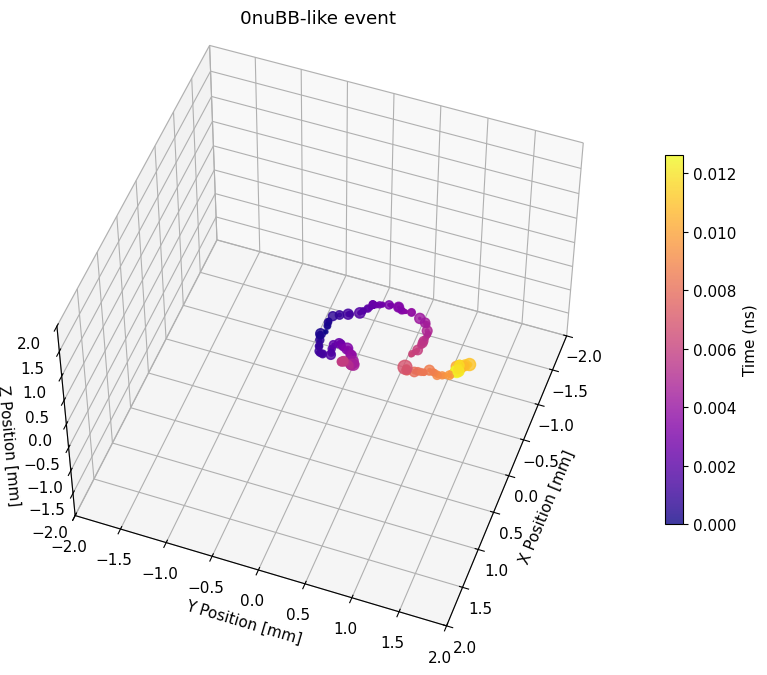

In [21]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams['font.size'] = 11

idx = 6

x = electrons_data['stepX'][idx]
y = electrons_data['stepY'][idx]
z = electrons_data['stepZ'][idx]
energy = electrons_data['stepEnergy_keV'][idx]
time = electrons_data['stepTime_ns'][idx]
srt = np.argsort(time)

# print('Range of event {}: {:4.4}mm'.format(idx, ComputeRange(x[srt],y[srt],z[srt])))

marker_sizes = (energy - min(energy)) / (max(energy) - min(energy)) * 100
time_normalized = time - min(time) #(time - min(time)) / (max(time) - min(time)) * 200

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(x[srt], y[srt], z[srt], s=marker_sizes[srt], c=time_normalized[srt], cmap='plasma', alpha=0.8)
# p = ax.plot(np.append([0.],x[srt]), np.append([0.],y[srt]), np.append([0.],z[srt]), '-k', linewidth=1)



box_size = 2.

ax.set_xlim(-box_size,box_size)
ax.set_ylim(-box_size,box_size)
ax.set_zlim(-box_size,box_size)
ax.view_init(elev=90, azim=0)
ax.view_init(elev=50, azim=20)

ax.set_xlabel("X Position [mm]")
ax.set_ylabel("Y Position [mm]")
ax.set_zlabel("Z Position [mm]")
ax.set_title("0nuBB-like event")

cbar = plt.colorbar(sc, ax=ax, shrink=0.6)
cbar.set_label("Time (ns)")

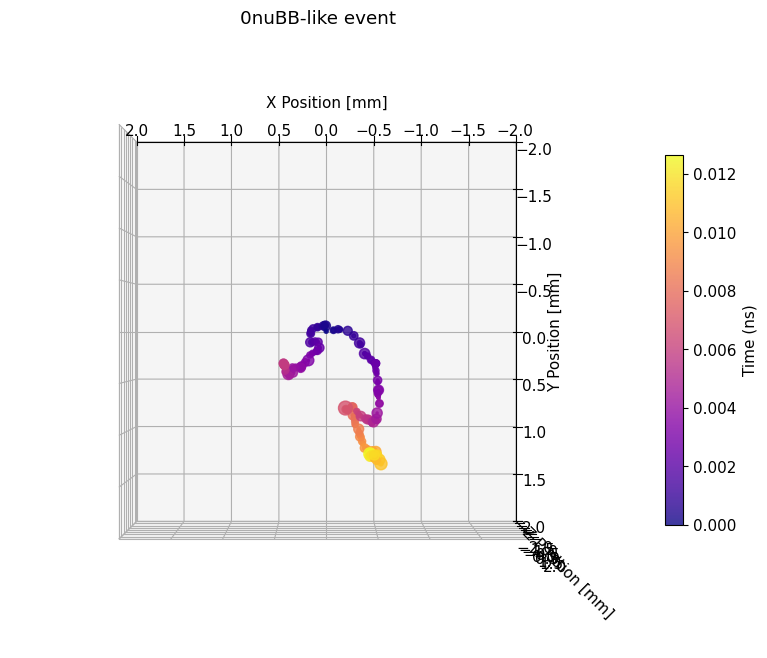

In [22]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams['font.size'] = 11


x = electrons_data['stepX'][idx]
y = electrons_data['stepY'][idx]
z = electrons_data['stepZ'][idx]
energy = electrons_data['stepEnergy_keV'][idx]
time = electrons_data['stepTime_ns'][idx]
srt = np.argsort(time)

# print('Range of event {}: {:4.4}mm'.format(idx, ComputeRange(x[srt],y[srt],z[srt])))

marker_sizes = (energy - min(energy)) / (max(energy) - min(energy)) * 100
time_normalized = time - min(time) #(time - min(time)) / (max(time) - min(time)) * 200

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(x[srt], y[srt], z[srt], s=marker_sizes[srt], c=time_normalized[srt], cmap='plasma', alpha=0.8)
# p = ax.plot(np.append([0.],x[srt]), np.append([0.],y[srt]), np.append([0.],z[srt]), '-k', linewidth=1)


box_size = 2.

ax.set_xlim(-box_size,box_size)
ax.set_ylim(-box_size,box_size)
ax.set_zlim(-box_size,box_size)
# set views so that we are looking down the z-axis, with x to the right and y up.
ax.view_init(elev=90, azim=90)
# ax.view_init(elev=50, azim=20)

ax.set_xlabel("X Position [mm]")
ax.set_ylabel("Y Position [mm]")
ax.set_zlabel("Z Position [mm]")
ax.set_title("0nuBB-like event")

cbar = plt.colorbar(sc, ax=ax, shrink=0.6)
cbar.set_label("Time (ns)")

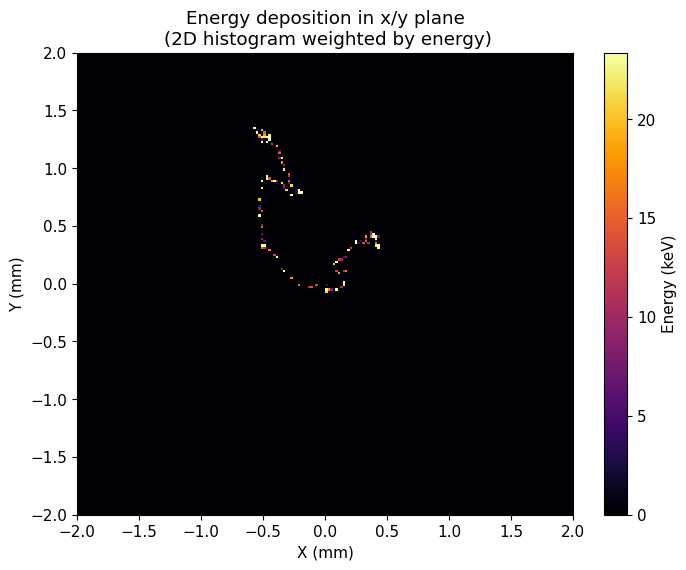

<Figure size 800x600 with 0 Axes>

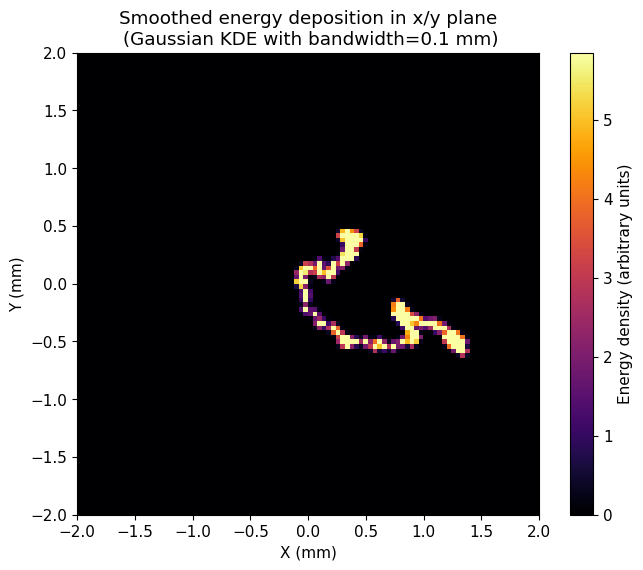

In [23]:
x = electrons_data['stepX'][idx]
y = electrons_data['stepY'][idx]
z = electrons_data['stepZ'][idx]
energy = electrons_data['stepEnergy_keV'][idx]
time = electrons_data['stepTime_ns'][idx]
srt = np.argsort(time)

# print('Range of event {}: {:4.4}mm'.format(idx, ComputeRange(x[srt],y[srt],z[srt])))

marker_sizes = (energy - min(energy)) / (max(energy) - min(energy)) * 100
time_normalized = time - min(time) #(time - min(time)) / (max(time) - min(time)) * 200


# Project that event onto the x/y plane to get a 2D histogram image. Weight each point by its energy deposition to get a sense of the energy density in different regions of the plane.
plt.figure(figsize=(8, 6))
plt.hist2d(x, y, bins=200, range=[[-box_size, box_size], [-box_size, box_size]], weights=energy, cmap='inferno', norm=plt.Normalize(vmin=0, vmax=np.percentile(energy, 99)))
plt.xlabel('X (mm)')
plt.ylabel('Y (mm)')
plt.title('Energy deposition in x/y plane\n (2D histogram weighted by energy)')
plt.colorbar(label='Energy (keV)')
# Set the colorscale to logarithmic to better see the structure in the energy deposition.
plt.figure(figsize=(8, 6))


# # Now plot it using a smoothed 2D histogram (gaussian kernel density estimation) to get a smoother image of the energy density in the x/y plane. Use a bandwidth of 0.1 mm for the kernel.
from scipy.ndimage import gaussian_filter
# Smooth the histogram above
hist, xedges, yedges = np.histogram2d(x, y, bins=100, range=[[-box_size, box_size], [-box_size, box_size]], weights=energy)
kde_values = gaussian_filter(hist, sigma=0.5) # convert bandwidth from mm to bins

plt.figure(figsize=(8, 6))
plt.imshow(kde_values, extent=(-box_size, box_size, -box_size, box_size), origin='lower', cmap='inferno', norm=plt.Normalize(vmin=0, vmax=np.percentile(kde_values, 99)))
plt.xlabel('X (mm)')
plt.ylabel('Y (mm)')
plt.title('Smoothed energy deposition in x/y plane\n (Gaussian KDE with bandwidth=0.1 mm)')
plt.colorbar(label='Energy density (arbitrary units)')  



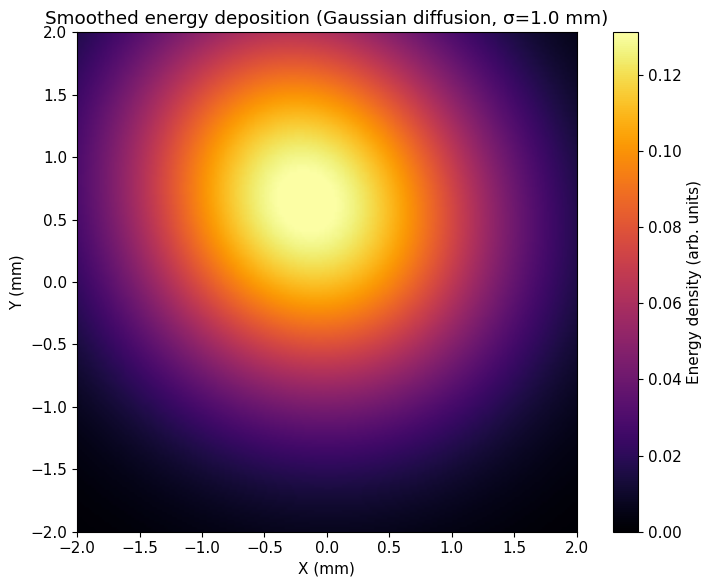

In [26]:

bins = 200
bandwidth_mm = 1.  # your desired diffusion length in mm
box_size = 2

# 2D energy histogram
hist, xedges, yedges = np.histogram2d(
    x, y,
    bins=bins,
    range=[[-box_size, box_size], [-box_size, box_size]],
    weights=energy
)

# Convert mm -> bins
dx = (2 * box_size) / bins  # mm/bin (same for x and y with your ranges)
sigma_bins = bandwidth_mm / dx

# Gaussian diffusion (smoothing)
smoothed = gaussian_filter(hist, sigma=sigma_bins, mode="constant")

# Plot
plt.figure(figsize=(8, 6))
plt.imshow(
    smoothed.T,  # transpose so x is horizontal and y is vertical (matches edges)
    extent=(-box_size, box_size, -box_size, box_size),
    origin="lower",
    cmap="inferno",
    vmin=0,
    vmax=np.percentile(smoothed, 99),
    aspect="equal"
)
plt.xlabel("X (mm)")
plt.ylabel("Y (mm)")
plt.title(f"Smoothed energy deposition (Gaussian diffusion, σ={bandwidth_mm} mm)")
plt.colorbar(label="Energy density (arb. units)")
plt.tight_layout()

In [34]:
print(electrons_data.keys())
print(electrons_data['stepX'].shape)
print(electrons_data['stepX'][0].shape)

dict_keys(['stepX', 'stepY', 'stepZ', 'stepEnergy_keV', 'stepTime_ns', 'trackID', 'parentID'])
(9999,)
(516,)


# Let's now look at aggregate properties of the $0\nu\beta\beta$ events. 

I want to look at: 
- Total energy in the event
- energy distributions for each electron
- Angular information

In [74]:
idx = 3

def CreateEventDict(electrons_data, idx):
    x = electrons_data['stepX'][idx]
    y = electrons_data['stepY'][idx]
    z = electrons_data['stepZ'][idx]
    energy = electrons_data['stepEnergy_keV'][idx]
    time = electrons_data['stepTime_ns'][idx]
    trackID = electrons_data['trackID'][idx]
    parentID = electrons_data['parentID'][idx]

    evt_dict = {'stepX': x, 'stepY': y, 'stepZ': z, 'stepEnergy_keV': energy, 'stepTime_ns': time, 'trackID': trackID, 'parentID': parentID}
    return evt_dict

def ReconstructTracks(evt_dict):
    # This function should produce three outputs: 1) the total energy deposited by electron 1, including all secondaries, 2) the total energy deposited by electron 2, including all secondaries,
    # and 3) the initial angle between the two electrons.
    # Note that the primary particles are the ones with parentID = 0. The secondaries will have parentID equal to the trackID of their parent.
    # First, we need to identify the two primary electrons. We can do this by finding the unique trackIDs with parentID = 0. Then we can sum the energy deposited by each primary and its secondaries.
    primary_trackIDs = np.unique(evt_dict['trackID'][evt_dict['parentID'] == 0])
    
    # Now that we have the primary trackID info, let's find the direction vector of each primary electron. We can do this by taking the first step of each primary electron and calculating the vector from the origin to that point.
    primary_directions = []
    for trackID in primary_trackIDs:
        primary_steps = np.where(evt_dict['trackID'] == trackID)[0]
        first_step = primary_steps[0]
        direction_vector = np.array([evt_dict['stepX'][first_step], evt_dict['stepY'][first_step], evt_dict['stepZ'][first_step]])
        primary_directions.append(direction_vector)
    angle = np.arccos(np.dot(primary_directions[0], primary_directions[1]) / (np.linalg.norm(primary_directions[0]) * np.linalg.norm(primary_directions[1])))
    
    # Next, we can sum the energy deposited by each primary and its secondaries. We can do this by finding all steps with the same trackID as the primary and summing their energies.
    total_energies = []
    for trackID in primary_trackIDs:
        total_energy = 0.
        steps = np.where(evt_dict['trackID'] == trackID)[0]
        total_energy += np.sum(evt_dict['stepEnergy_keV'][steps])
        # List all tracks with parentID equal to this trackID (these are the secondaries) and sum their energies as well.
        secondary_trackIDs = np.unique(evt_dict['trackID'][evt_dict['parentID'] == trackID])
        for secondary_trackID in secondary_trackIDs:
            secondary_steps = np.where(evt_dict['trackID'] == secondary_trackID)[0]
            total_energy += np.sum(evt_dict['stepEnergy_keV'][secondary_steps]) 
            # Next do tertiary tracks (secondaries of secondaries) and sum their energies as well.
            tertiary_trackIDs = np.unique(evt_dict['trackID'][evt_dict['parentID'] == secondary_trackID])
            for tertiary_trackID in tertiary_trackIDs:
                tertiary_steps = np.where(evt_dict['trackID'] == tertiary_trackID)[0]
                total_energy += np.sum(evt_dict['stepEnergy_keV'][tertiary_steps])
                # Next do quaternary tracks (secondaries of tertiaries) and sum their energies as well.
                quaternary_trackIDs = np.unique(evt_dict['trackID'][evt_dict['parentID'] == tertiary_trackID])
                for quaternary_trackID in quaternary_trackIDs:
                    quaternary_steps = np.where(evt_dict['trackID'] == quaternary_trackID)[0]
                    total_energy += np.sum(evt_dict['stepEnergy_keV'][quaternary_steps])
                    # Next do quinary tracks (secondaries of quaternaries) and sum their energies as well.
                    quinary_trackIDs = np.unique(evt_dict['trackID'][evt_dict['parentID'] == quaternary_trackID])
                    for quinary_trackID in quinary_trackIDs:
                        quinary_steps = np.where(evt_dict['trackID'] == quinary_trackID)[0]
                        total_energy += np.sum(evt_dict['stepEnergy_keV'][quinary_steps])
                        # Next do senary tracks (secondaries of quinaries) and sum their energies as well.
                        senary_trackIDs = np.unique(evt_dict['trackID'][evt_dict['parentID'] == quinary_trackID])
                        for senary_trackID in senary_trackIDs:
                            senary_steps = np.where(evt_dict['trackID'] == senary_trackID)[0]
                            total_energy += np.sum(evt_dict['stepEnergy_keV'][senary_steps])
                            # Next do septenary tracks (secondaries of senaries) and sum their energies as well.
                            septenary_trackIDs = np.unique(evt_dict['trackID'][evt_dict['parentID'] == senary_trackID])
                            for septenary_trackID in septenary_trackIDs:
                                septenary_steps = np.where(evt_dict['trackID'] == septenary_trackID)[0]
                                total_energy += np.sum(evt_dict['stepEnergy_keV'][septenary_steps])
                                # Next do octonary tracks (secondaries of septenaries) and sum their energies as well.
                                octonary_trackIDs = np.unique(evt_dict['trackID'][evt_dict['parentID'] == septenary_trackID])
                                for octonary_trackID in octonary_trackIDs:
                                    octonary_steps = np.where(evt_dict['trackID'] == octonary_trackID)[0]
                                    total_energy += np.sum(evt_dict['stepEnergy_keV'][octonary_steps])
                                    # Next do nonary tracks (secondaries of octonaries) and sum their energies as well.
                                    nonary_trackIDs = np.unique(evt_dict['trackID'][evt_dict['parentID'] == octonary_trackID])
                                    for nonary_trackID in nonary_trackIDs:
                                        nonary_steps = np.where(evt_dict['trackID'] == nonary_trackID)[0]
                                        total_energy += np.sum(evt_dict['stepEnergy_keV'][nonary_steps])
                                        # Next do denary tracks (secondaries of nonaries) and sum their energies as well.
                                        denary_trackIDs = np.unique(evt_dict['trackID'][evt_dict['parentID'] == nonary_trackID])
                                        for denary_trackID in denary_trackIDs:
                                            denary_steps = np.where(evt_dict['trackID'] == denary_trackID)[0]
                                            total_energy += np.sum(evt_dict['stepEnergy_keV'][denary_steps])
                    
        total_energies.append(total_energy)
        
    return total_energies[0], total_energies[1], angle


    

In [75]:
idx = 100
evt_dict = CreateEventDict(electrons_data, idx)
e1, e2, angle = ReconstructTracks(evt_dict)
print(e1 + e2)

2457.7999999999993


In [80]:
e1_energies = []
e2_energies = []
total_energies = []
angles = []

nevts = 10000

for idx in range(len(electrons_data['stepX'])):
    if idx % 100 == 0:
        print('Processing event {} of {}'.format(idx, len(electrons_data['stepX'])))
    if idx >= nevts:
        break
    evt_dict = CreateEventDict(electrons_data, idx)
    e1, e2, angle = ReconstructTracks(evt_dict)
    e1_energies.append(e1)
    e2_energies.append(e2)
    total_energies.append(e1 + e2)
    angles.append(angle)
    
e1_energies = np.array(e1_energies)
e2_energies = np.array(e2_energies)
total_energies = np.array(total_energies)
angles = np.array(angles)

Processing event 0 of 9999
Processing event 100 of 9999
Processing event 200 of 9999
Processing event 300 of 9999
Processing event 400 of 9999
Processing event 500 of 9999
Processing event 600 of 9999
Processing event 700 of 9999
Processing event 800 of 9999
Processing event 900 of 9999
Processing event 1000 of 9999
Processing event 1100 of 9999
Processing event 1200 of 9999
Processing event 1300 of 9999
Processing event 1400 of 9999
Processing event 1500 of 9999
Processing event 1600 of 9999
Processing event 1700 of 9999
Processing event 1800 of 9999
Processing event 1900 of 9999
Processing event 2000 of 9999
Processing event 2100 of 9999
Processing event 2200 of 9999
Processing event 2300 of 9999
Processing event 2400 of 9999
Processing event 2500 of 9999
Processing event 2600 of 9999
Processing event 2700 of 9999
Processing event 2800 of 9999
Processing event 2900 of 9999
Processing event 3000 of 9999
Processing event 3100 of 9999
Processing event 3200 of 9999
Processing event 3300 

Text(0.5, 1.0, 'Angle Distribution between Electrons in 0vbb Events')

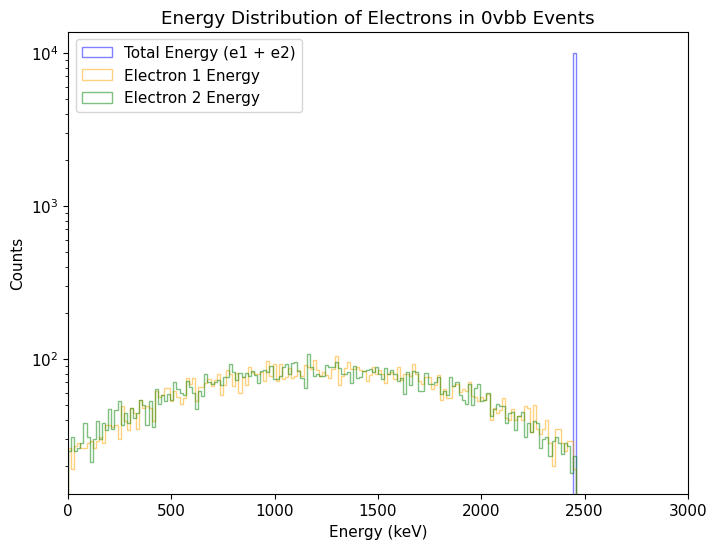

<Figure size 640x480 with 0 Axes>

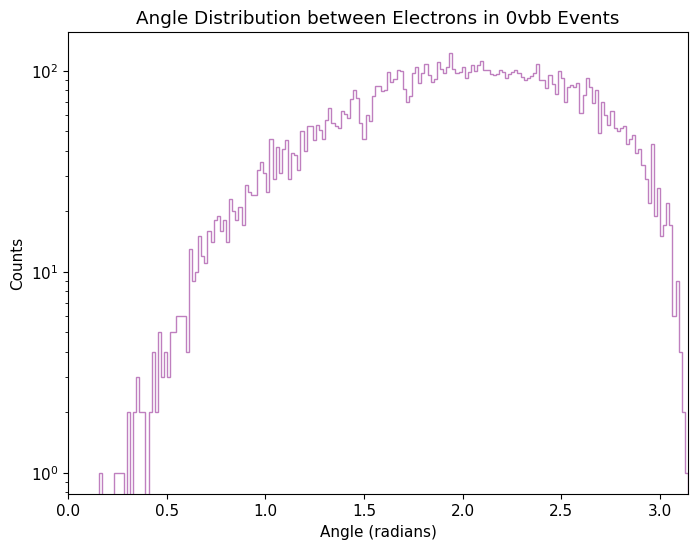

In [81]:
# Plot histograms of the energies and angles. make the histograms step-like (not filled)
plt.figure(figsize=(8, 6))
plt.hist(total_energies, bins=200, range=(0, 3000), alpha=0.5, label='Total Energy (e1 + e2)', color='blue', histtype='step')
plt.hist(e1_energies, bins=200, range=(0, 3000), alpha=0.5, label='Electron 1 Energy', color='orange', histtype='step')
plt.hist(e2_energies, bins=200, range=(0, 3000), alpha=0.5, label='Electron 2 Energy', color='green', histtype='step')
plt.xlabel('Energy (keV)')

plt.yscale('log')
plt.xlim(0, 3000)
plt.ylabel('Counts')
plt.title('Energy Distribution of Electrons in 0vbb Events')
plt.legend()

plt.figure(2)
plt.figure(figsize=(8, 6))
plt.hist(angles, bins=200, range=(0, np.pi), alpha=0.5, label='Angle between electrons', color='purple', histtype='step')
plt.xlabel('Angle (radians)')
plt.yscale('log')
plt.xlim(0, np.pi)
plt.ylabel('Counts')
plt.title('Angle Distribution between Electrons in 0vbb Events')